### Imports and Paths


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

### Load Datasets


In [2]:
from src.preprocessing import load_data

train_path = PROJECT_ROOT / "data" / "train-test.csv"
validation_path = PROJECT_ROOT / "data" / "validation.csv"

train_df = load_data(train_path)
validation_df = load_data(validation_path)

print("Training data:", train_df.shape)
print("Validation data:", validation_df.shape)

Training data: (48000, 14)
Validation data: (12000, 13)


### Column Names


In [3]:
print("Training columns:")
for column in train_df.columns:
    print(column)

print("\nValidation columns:")
for column in validation_df.columns:
    print(column)

Training columns:
load_id
pickup
delivery
pickup_lat
pickup_lon
delivery_lat
delivery_lon
distance
equipment
weight
date
market_index
quote_signal
posted_rate

Validation columns:
load_id
pickup
delivery
pickup_lat
pickup_lon
delivery_lat
delivery_lon
distance
equipment
weight
date
market_index
quote_signal


### Data Types


In [4]:
print("Training data types:")
print(train_df.dtypes)

print("\nValidation data types:")
print(validation_df.dtypes)

Training data types:
load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

Validation data types:
load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
dtype: object


### Basic Information


In [5]:
train_df.info()
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   load_id       48000 non-null  object        
 1   pickup        48000 non-null  object        
 2   delivery      48000 non-null  object        
 3   pickup_lat    48000 non-null  float64       
 4   pickup_lon    48000 non-null  float64       
 5   delivery_lat  48000 non-null  float64       
 6   delivery_lon  48000 non-null  float64       
 7   distance      48000 non-null  float64       
 8   equipment     48000 non-null  object        
 9   weight        47700 non-null  float64       
 10  date          48000 non-null  datetime64[ns]
 11  market_index  47626 non-null  float64       
 12  quote_signal  48000 non-null  float64       
 13  posted_rate   48000 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(4)
memory usage: 5.1+ MB
<class 'pandas.core.

### Sample Records


In [6]:
train_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [7]:
validation_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


### Missing Values


In [8]:
train_missing = (
    train_df.isna().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("Training missing values:")
print(train_missing)

Training missing values:
market_index    374
weight          300
dtype: int64


In [9]:
validation_missing = (
    validation_df.isna().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("Validation missing values:")
print(validation_missing)

Validation missing values:
market_index    249
weight          165
dtype: int64


### Duplicate Checks


In [10]:
print(
    "Training exact duplicate rows:",
    train_df.duplicated().sum()
)

print(
    "Validation exact duplicate rows:",
    validation_df.duplicated().sum()
)

print(
    "Training duplicate load_id values:",
    train_df["load_id"].duplicated().sum()
)

print(
    "Validation duplicate load_id values:",
    validation_df["load_id"].duplicated().sum()
)

Training exact duplicate rows: 0
Validation exact duplicate rows: 0
Training duplicate load_id values: 0
Validation duplicate load_id values: 0


### Date Range


In [11]:
print("Training period:")
print("Start:", train_df["date"].min().date())
print("End:  ", train_df["date"].max().date())

print("\nValidation period:")
print("Start:", validation_df["date"].min().date())
print("End:  ", validation_df["date"].max().date())

Training period:
Start: 2025-01-01
End:   2025-10-31

Validation period:
Start: 2025-11-01
End:   2025-12-31


### Numerical Sanity Checks


In [12]:
coordinate_columns = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
]

print("Training coordinate ranges:")
print(train_df[coordinate_columns].agg(["min", "max"]).T)

print("\nValidation coordinate ranges:")
print(validation_df[coordinate_columns].agg(["min", "max"]).T)

nonnegative_columns_train = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate",
]

nonnegative_columns_validation = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
]

negative_values_train = {
    column: (train_df[column] < 0).sum()
    for column in nonnegative_columns_train
}

negative_values_validation = {
    column: (validation_df[column] < 0).sum()
    for column in nonnegative_columns_validation
}

print("\nTraining negative values:")
print(pd.Series(negative_values_train))

print("\nValidation negative values:")
print(pd.Series(negative_values_validation))

Training coordinate ranges:
                    min       max
pickup_lat     28.35765  44.30296
pickup_lon   -121.69849 -69.50000
delivery_lat   28.35765  44.30296
delivery_lon -121.69849 -69.50000

Validation coordinate ranges:
                    min       max
pickup_lat     25.50000  44.30296
pickup_lon   -121.69849 -69.50000
delivery_lat   25.50000  44.30296
delivery_lon -121.69849 -69.50000

Training negative values:
distance          0
weight          292
market_index      0
quote_signal      0
posted_rate       0
dtype: int64

Validation negative values:
distance          0
weight          145
market_index      0
quote_signal      0
dtype: int64


### Numerical Summary


In [13]:
train_df.describe().T

,count,mean,min,25%,50%,75%,max,std
pickup_lat,48000.0,35.647545,28.35765,31.98691,35.29479,39.41104,44.30296,4.315285
pickup_lon,48000.0,-90.928964,-121.69849,-98.40059,-88.08915,-83.28506,-69.5,13.482431
delivery_lat,48000.0,35.641175,28.35765,31.98691,35.29479,39.41104,44.30296,4.317199
delivery_lon,48000.0,-90.85731,-121.69849,-98.40059,-87.52871,-83.28506,-69.5,13.476589
distance,48000.0,1135.856654,70.0,550.4,953.3,1645.525,3439.8,728.564416
weight,47700.0,31028.844004,-47500.0,25800.0,31436.5,37018.0,47500.0,9391.44062
date,48000,2025-05-31 19:53:29.400000,2025-01-01 00:00:00,2025-03-18 00:00:00,2025-05-31 00:00:00,2025-08-15 00:00:00,2025-10-31 00:00:00,NaN
market_index,47626.0,1.083387,0.67639,0.94967,1.0558,1.21959,1.46778,0.168091
quote_signal,48000.0,2.062468,0.69228,1.89103,2.05575,2.221685,3.61035,0.291391
posted_rate,48000.0,2373.980682,57.22,1251.555,2030.76,3330.75,25533.0,1486.493245


### Categorical Variables


In [14]:
categorical_columns = [
    "pickup",
    "delivery",
    "equipment",
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(
        "Unique values:",
        train_df[column].nunique(dropna=False)
    )
    print(
        train_df[column]
        .value_counts(dropna=False)
        .head(10)
    )


--- pickup ---
Unique values: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Name: count, dtype: int64

--- delivery ---
Unique values: 64
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Name: count, dtype: int64

--- equipment ---
Unique values: 3
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


### Categorical Missing Values


In [15]:
categorical_missing = pd.DataFrame({
    "training": train_df[categorical_columns].isna().sum(),
    "validation": validation_df[categorical_columns].isna().sum(),
})

categorical_missing

,training,validation
pickup,0,0
delivery,0,0
equipment,0,0


### Target Distribution


In [16]:
train_df["posted_rate"].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

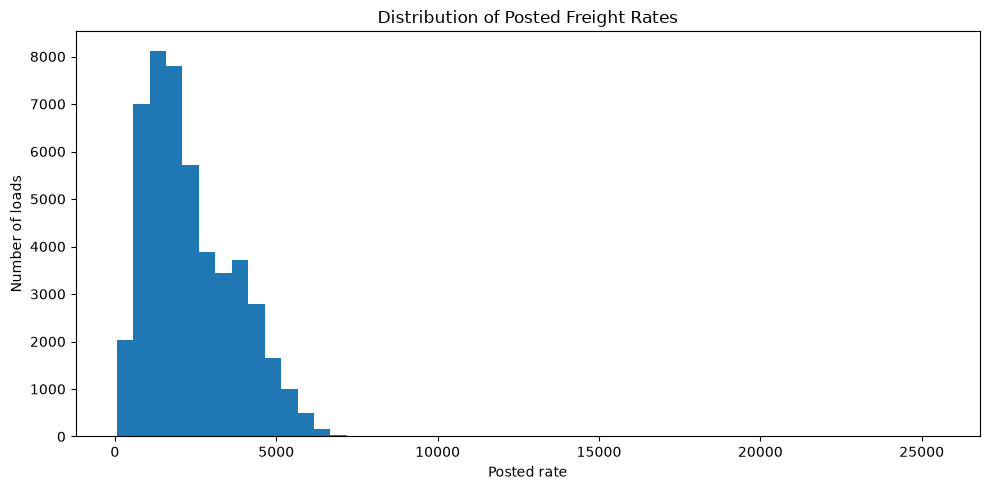

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["posted_rate"],
    bins=50,
)

plt.xlabel("Posted rate")
plt.ylabel("Number of loads")
plt.title("Distribution of Posted Freight Rates")
plt.tight_layout()
plt.show()

### Monthly Target Trend


In [18]:
monthly_rates = (
    train_df
    .assign(month=train_df["date"].dt.to_period("M"))
    .groupby("month")["posted_rate"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

monthly_rates

,month,mean,median,count
0,2025-01,2255.967048,1915.200,4918
1,2025-02,2273.804801,1994.250,4337
2,2025-03,2372.268092,2022.920,5036
3,2025-04,2372.162308,2044.240,4819
4,2025-05,2421.776342,2065.510,4913
5,2025-06,2497.030115,2120.220,4783
6,2025-07,2415.162030,2059.145,4912
7,2025-08,2338.407661,2015.730,4759
8,2025-09,2406.374013,2057.130,4670
9,2025-10,2379.051374,2035.900,4853


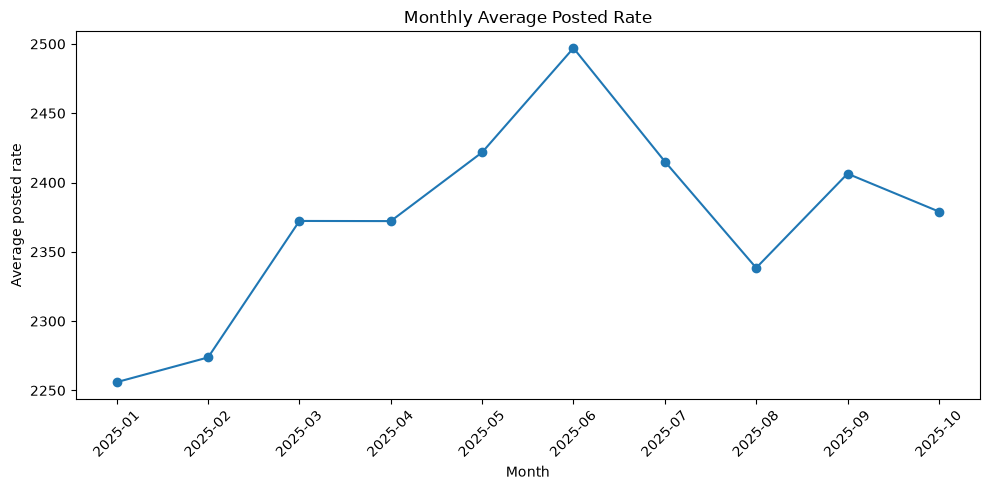

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_rates["month"].astype(str),
    monthly_rates["mean"],
    marker="o",
)

plt.xlabel("Month")
plt.ylabel("Average posted rate")
plt.title("Monthly Average Posted Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Relationship Between Distance and Posted Rate


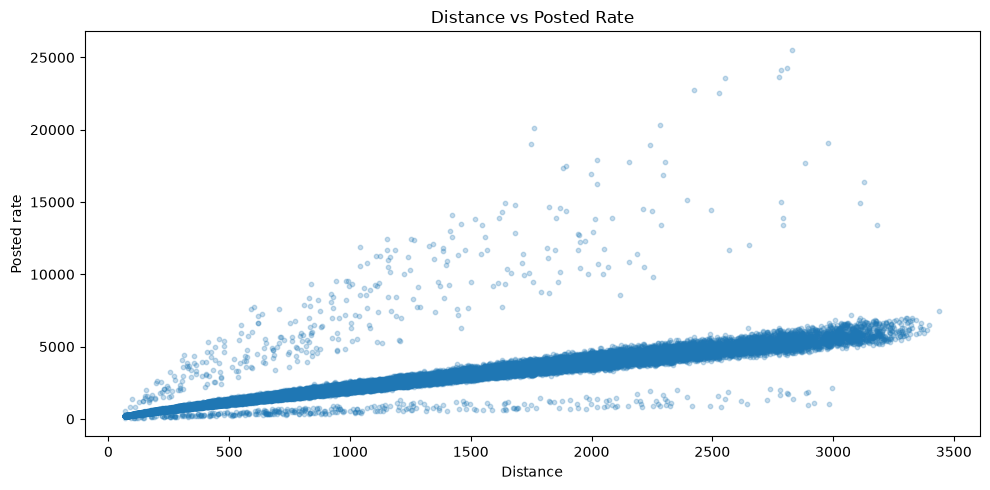

In [20]:
plt.figure(figsize=(10, 5))

plt.scatter(
    train_df["distance"],
    train_df["posted_rate"],
    alpha=0.25,
    s=10,
)

plt.xlabel("Distance")
plt.ylabel("Posted rate")
plt.title("Distance vs Posted Rate")
plt.tight_layout()
plt.show()

### Investigating December Chart Inputs


In [21]:
december_path = (
    PROJECT_ROOT
    / "data"
    / "december-chart-inputs.csv"
)

december_df = pd.read_csv(december_path)

print("Shape:", december_df.shape)

print("\nColumns:")
print(december_df.columns.tolist())

print("\nData types:")
print(december_df.dtypes)

print("\nMissing values:")
print(december_df.isna().sum())

print("\nMissing categorical values:")
print(
    december_df[["pickup", "delivery", "equipment"]]
    .isna()
    .sum()
)

print("\nNegative weight:",
      (december_df["weight"] < 0).sum())

print("Negative distance:",
      (december_df["distance"] < 0).sum())

Shape: (31, 7)

Columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

Data types:
pickup             object
delivery           object
distance            int64
equipment          object
weight              int64
date               object
predicted_rate    float64
dtype: object

Missing values:
pickup             0
delivery           0
distance           0
equipment          0
weight             0
date               0
predicted_rate    31
dtype: int64

Missing categorical values:
pickup       0
delivery     0
equipment    0
dtype: int64

Negative weight: 0
Negative distance: 0


### Feature Availability Check


In [22]:
from src.preprocessing import (
    clean_data,
    prepare_december_data,
    build_coordinate_lookup,
    add_coordinates,
)

from src.features import create_features


# Create modeling copies without changing the raw EDA data.
train_clean_df = clean_data(train_df)
validation_clean_df = clean_data(validation_df)


# Training features.
train_features = create_features(
    train_clean_df
)


# Validation features.
validation_features = create_features(
    validation_clean_df
)


# December features.
december_df = pd.read_csv(december_path)
december_df = prepare_december_data(december_df)

coordinate_lookup = build_coordinate_lookup(
    train_clean_df
)

december_df = add_coordinates(
    december_df,
    coordinate_lookup,
)

december_features = create_features(
    december_df
)


print("Training features:")
print(train_features.columns.tolist())

print("\nValidation features:")
print(validation_features.columns.tolist())

print("\nDecember features:")
print(december_features.columns.tolist())

print(
    "\nTraining == Validation:",
    list(train_features.columns)
    == list(validation_features.columns),
)

print(
    "Training == December:",
    list(train_features.columns)
    == list(december_features.columns),
)


Training features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'month', 'day_of_week', 'day_of_year', 'days_since_start', 'route', 'weight_missing']

Validation features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'month', 'day_of_week', 'day_of_year', 'days_since_start', 'route', 'weight_missing']

December features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'month', 'day_of_week', 'day_of_year', 'days_since_start', 'route', 'weight_missing']

Training == Validation: True
Training == December: True


In [23]:
print("December coordinate missing values:")

coordinate_columns = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
]

print(
    december_df[coordinate_columns]
    .isna()
    .sum()
)

print("\nFeature shapes:")
print("Training:", train_features.shape)
print("Validation:", validation_features.shape)
print("December:", december_features.shape)


December coordinate missing values:
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
dtype: int64

Feature shapes:
Training: (48000, 15)
Validation: (12000, 15)
December: (31, 15)


In [24]:
december_features.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,month,day_of_week,day_of_year,days_since_start,route,weight_missing
0,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206,360,Dry Van,32000,12,0,335,334,Lexington__Fort Wayne,0
1,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206,360,Dry Van,32000,12,1,336,335,Lexington__Fort Wayne,0
2,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206,360,Dry Van,32000,12,2,337,336,Lexington__Fort Wayne,0
3,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206,360,Dry Van,32000,12,3,338,337,Lexington__Fort Wayne,0
4,Lexington,Fort Wayne,36.99152,-84.99876,41.31561,-85.36206,360,Dry Van,32000,12,4,339,338,Lexington__Fort Wayne,0


### Data Preparation Check


In [25]:
print("Negative training weights after cleaning:",
      (train_clean_df["weight"] < 0).sum())

print("Negative validation weights after cleaning:",
      (validation_clean_df["weight"] < 0).sum())

Negative training weights after cleaning: 0
Negative validation weights after cleaning: 0


## Walk-Forward Model Validation


In [26]:
from src.validation import evaluate_models

model_names = [
    "median_baseline",
    "lightgbm",
    "catboost",
]

X = create_features(
    train_clean_df
)

y = train_clean_df["posted_rate"]


In [27]:
results = evaluate_models(
    df=train_clean_df,
    X=X,
    model_names=model_names,
)

results

median_baseline  Fold 1 | MAE: 1,144.37 | RMSE: 1,555.08 | R²: -0.0680
median_baseline  Fold 2 | MAE: 1,111.35 | RMSE: 1,507.32 | R²: -0.0446
median_baseline  Fold 3 | MAE: 1,151.11 | RMSE: 1,570.08 | R²: -0.0623
median_baseline  Fold 4 | MAE: 1,146.79 | RMSE: 1,567.97 | R²: -0.0522
lightgbm         Fold 1 | MAE: 276.25 | RMSE: 756.63 | R²: 0.7472
lightgbm         Fold 2 | MAE: 228.64 | RMSE: 816.05 | R²: 0.6938
lightgbm         Fold 3 | MAE: 204.26 | RMSE: 713.85 | R²: 0.7804
lightgbm         Fold 4 | MAE: 231.62 | RMSE: 708.59 | R²: 0.7851
catboost         Fold 1 | MAE: 173.44 | RMSE: 637.22 | R²: 0.8207
catboost         Fold 2 | MAE: 143.03 | RMSE: 619.56 | R²: 0.8235
catboost         Fold 3 | MAE: 114.40 | RMSE: 616.55 | R²: 0.8362
catboost         Fold 4 | MAE: 127.62 | RMSE: 647.03 | R²: 0.8208


,model,fold,train_rows,valid_rows,mae,rmse,r2
0,median_baseline,1,28806,4912,1144.371439,1555.078963,-0.067955
1,median_baseline,2,33718,4759,1111.351386,1507.319146,-0.044551
2,median_baseline,3,38477,4670,1151.114463,1570.082929,-0.062337
3,median_baseline,4,43147,4853,1146.793707,1567.970485,-0.052235
4,lightgbm,1,28806,4912,276.252984,756.631910,0.747176
5,lightgbm,2,33718,4759,228.640371,816.054689,0.693833
6,lightgbm,3,38477,4670,204.259962,713.850343,0.780400
7,lightgbm,4,43147,4853,231.622048,708.589266,0.785105
8,catboost,1,28806,4912,173.443434,637.223833,0.820679
9,catboost,2,33718,4759,143.031711,619.558454,0.823525


### Mean Validation Metrics


In [28]:
model_summary = (
    results
    .groupby("model")[["mae", "rmse", "r2"]]
    .mean()
    .reset_index()
)

model_summary

,model,mae,rmse,r2
0,catboost,139.625963,630.090842,0.825302
1,lightgbm,235.193841,748.781552,0.751629
2,median_baseline,1138.407749,1550.112881,-0.056770


### Select the Model


In [29]:
selected_model = (
    model_summary
    .sort_values("mae")
    .iloc[0]["model"]
)

print("Selected model:", selected_model)

Selected model: catboost


### Validation Prediction File Check

In [31]:
predictions = pd.read_csv(
    r"F:\Spotter_Assessment\validation_predictions.csv"
)

print("Shape:", predictions.shape)
print("Columns:", predictions.columns.tolist())
print("Unique load_id:", predictions["load_id"].nunique())
print(
    "Missing predictions:",
    predictions["predicted_rate"].isna().sum()
)
print(
    "Non-positive predictions:",
    (predictions["predicted_rate"] <= 0).sum()
)

Shape: (12000, 2)
Columns: ['load_id', 'predicted_rate']
Unique load_id: 12000
Missing predictions: 0
Non-positive predictions: 0


### December Prediction File Check

In [32]:
december_check = pd.read_csv(
    r"F:\Spotter_Assessment\data\december-chart-inputs.csv"
)

print("Shape:", december_check.shape)
print("Columns:", december_check.columns.tolist())
print(
    "Missing predictions:",
    december_check["predicted_rate"].isna().sum()
)
print(
    "Non-positive predictions:",
    (december_check["predicted_rate"] <= 0).sum()
)

Shape: (31, 7)
Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
Missing predictions: 0
Non-positive predictions: 0


### Validation Prediction Summary

In [37]:
train_df["posted_rate"].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

In [38]:
predictions["predicted_rate"].describe()

count    12000.000000
mean      2419.009465
std       1410.823616
min        121.726479
25%       1299.453849
50%       2070.771604
75%       3465.558930
max       8926.022470
Name: predicted_rate, dtype: float64

### Training Target vs Validation Prediction Comparison

In [42]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

VALIDATION_PREDICTIONS_PATH = (
    PROJECT_ROOT / "validation_predictions.csv"
)


train_df = pd.read_csv(
    DATA_DIR / "train-test.csv"
)

val_df = pd.read_csv(
    DATA_DIR / "validation.csv"
)

val_preds = pd.read_csv(
    VALIDATION_PREDICTIONS_PATH
)


val_df = val_df.merge(
    val_preds,
    on="load_id",
    how="left",
)

In [43]:
def distribution_summary(series, name):
    """Return a summary dict of key statistics for a pandas Series."""
    return {
        "Metric": [
            "Count", "Mean", "Median", "Std",
            "Min", "25th pct", "75th pct", "Max",
        ],
        name: [
            f"{series.count():,.0f}",
            f"{series.mean():,.0f}",
            f"{series.median():,.0f}",
            f"{series.std():,.0f}",
            f"{series.min():,.0f}",
            f"{series.quantile(0.25):,.0f}",
            f"{series.quantile(0.75):,.0f}",
            f"{series.max():,.0f}",
        ],
    }


summary = (
    pd.DataFrame(distribution_summary(train_df["posted_rate"], "Training"))
      .merge(
          pd.DataFrame(distribution_summary(val_df["predicted_rate"], "Validation")),
          on="Metric",
      )
)


def pct_change(t, v):
    """Return percentage difference as a signed string."""
    try:
        t_f = float(t.replace(",", ""))
        v_f = float(v.replace(",", ""))
        if t_f == 0:
            return "—"
        return f"{(v_f / t_f - 1) * 100:+.1f}%"
    except Exception:
        return "—"


PCT_ROWS = {"Mean", "Median", "Std", "25th pct", "75th pct"}

summary["Diff"] = [
    pct_change(row["Training"], row["Validation"])
    if row["Metric"] in PCT_ROWS else "—"
    for _, row in summary.iterrows()
]

summary

,Metric,Training,Validation,Diff
0,Count,"48,000","12,000",—
1,Mean,"2,374","2,419",+1.9%
2,Median,"2,031","2,071",+2.0%
3,Std,"1,486","1,411",-5.0%
4,Min,57,122,—
5,25th pct,"1,252","1,299",+3.8%
6,75th pct,"3,331","3,466",+4.1%
7,Max,"25,533","8,926",—
